# MDC Anomaly Detection -- Model v3 (Exp 1)

Loads `windows_v3.npz` from `mdc_preprocess_v3.ipynb` **Exp 1** (T=10, mean-only buckets, StandardScaler + clip).

**Exp 1 model settings (aligned with v2 baseline):**

| Component | v3 (failed) | **Exp 1** |
|---|---|---|
| Input shape | T=25, ~166 feat | **T=10, ~55 feat** |
| Bottleneck | 16 | **32** (v2 default) |
| Loss | Huber | **MSE** |
| Early stopping | benign MSE primary | **val ROC-AUC primary** |
| Checkpoint restore | AUC > 0.55 | **AUC > 0.50** |

Other v3 improvements kept: learned pos_queries decoder, variance-weighted scoring, dual thresholds.

## 0. Environment

In [1]:
import sys, subprocess

try:
    import google.colab
    _IN_COLAB = True
except ImportError:
    _IN_COLAB = False

if _IN_COLAB:
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q',
         'torch', 'scikit-learn', 'matplotlib', 'optuna'],
        check=False,
    )

print(f'Running in Colab: {_IN_COLAB}')

Running in Colab: True


## 1. Configuration

In [2]:
from __future__ import annotations
import json, os, random, gc
from pathlib import Path
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Training
BATCH_SIZE   = 32
MAX_EPOCHS   = 100
PATIENCE     = 20
LR           = 5e-4
WEIGHT_DECAY = 1e-4
DROPOUT      = 0.15
GRAD_CLIP    = 1.0

# Exp 1: MSE loss (v2-aligned) + AUC-first early stopping
LOSS_FN          = 'mse'
AUC_RESTORE_MIN  = 0.50   # restore AUC checkpoint when val AUC exceeds this
AUC_EARLY_STOP   = True    # stop when val AUC plateaus (primary)

# Architecture
D_MODEL        = 64
N_HEAD         = 4
N_ENC_LAYERS   = 2
N_DEC_LAYERS   = 1
DIM_FF         = 192    # 3x d_model (correct ratio)
BOTTLENECK_DIM = 32     # v2 default — less aggressive than 16

# Denoising
USE_DENOISING = True
NOISE_STD     = 0.05

# Scoring
SCORE_MEAN_W     = 0.7
SCORE_MAX_W      = 0.3
SCORE_BATCH_SIZE = 128
AUC_CHECK_FREQ   = 3    # ROC-AUC check every N epochs (more frequent than v3.0)

# HPO
N_TRIALS      = 15
HPO_MAX_EPOCH = 30
HPO_PATIENCE  = 8

# ── Data source ────────────────────────────────────────────────────────────────
# Requires mdc_preprocess_v3.ipynb Exp 1:
#   random session split + benign-only StandardScaler fit + post-scale clip
#   mean-only buckets, T=10, STRIDE=2, ATTACK_FRAC_THRESHOLD=0.5
NPZ_FILE = 'windows_v3.npz'

if _IN_COLAB:
    RUN_DIR  = Path('/content/drive/MyDrive/Module4_MDC/runs/v3_run')
    DATA_DIR = Path('/content/drive/MyDrive/Module4_MDC/processed_v3')
else:
    RUN_DIR  = Path('../outputs/mdc_v3_run')
    DATA_DIR = Path('../data/processed')

print('Config loaded.')
print(f'  NPZ_FILE       : {NPZ_FILE}')
print(f'  DATA_DIR       : {DATA_DIR}')
print(f'  Architecture   : D_MODEL={D_MODEL}  BOTTLENECK={BOTTLENECK_DIM}  DIM_FF={DIM_FF}')
print(f'                   N_ENC={N_ENC_LAYERS}  N_DEC={N_DEC_LAYERS}  N_HEAD={N_HEAD}')
print(f'  Training       : LR={LR}  BATCH={BATCH_SIZE}  MAX_EPOCHS={MAX_EPOCHS}')
print(f'  Loss           : {LOSS_FN.upper()} (exp1)')
print(f'  Early stop     : val ROC-AUC primary (restore if > {AUC_RESTORE_MIN})')
print(f'  AUC check freq : every {AUC_CHECK_FREQ} epochs')

Config loaded.
  NPZ_FILE       : windows_v3.npz
  DATA_DIR       : /content/drive/MyDrive/Module4_MDC/processed_v3
  Architecture   : D_MODEL=64  BOTTLENECK=32  DIM_FF=192
                   N_ENC=2  N_DEC=1  N_HEAD=4
  Training       : LR=0.0005  BATCH=32  MAX_EPOCHS=100
  Loss           : MSE (exp1)
  Early stop     : val ROC-AUC primary (restore if > 0.5)
  AUC check freq : every 3 epochs


## 2. Mount Drive & Load `windows_v3.npz`

In [3]:
import os, shutil, gc
from pathlib import Path
import numpy as np

if _IN_COLAB:
    from google.colab import drive
    _mount = '/content/drive'
    if not os.path.isdir(os.path.join(_mount, 'MyDrive')):
        os.makedirs(_mount, exist_ok=True)
        drive.mount(_mount)

NPZ_PATH = DATA_DIR / NPZ_FILE

# If primary path missing OR stale (RobustScaler-era file), search Module4_MDC
def _npz_scale_ok(path: Path) -> bool:
    try:
        z = np.load(path)
        xt = z['X_train'].astype(np.float32)
        z.close()
        return float(np.abs(xt).max()) <= 50
    except Exception:
        return False

if _IN_COLAB and NPZ_PATH.is_file() and not _npz_scale_ok(NPZ_PATH):
    print(f'WARN: {NPZ_PATH} has bad scale (likely old RobustScaler export) — searching for replacement')
    NPZ_PATH = DATA_DIR / '___missing___'

if not NPZ_PATH.is_file() and _IN_COLAB:
    myd = Path('/content/drive/MyDrive')
    # Prefer Exp 1 export folder; never grab arbitrary shortest-path duplicates
    candidates = [
        myd / 'Module4_MDC' / 'processed_v3' / NPZ_FILE,
        myd / 'Module4_MDC' / 'processed' / NPZ_FILE,
    ]
    candidates += sorted(
        (p for p in myd.rglob(NPZ_FILE) if 'Module4_MDC' in str(p)),
        key=lambda p: len(str(p)),
    )
    seen, hits = set(), []
    for p in candidates:
        if p.is_file() and p not in seen:
            hits.append(p)
            seen.add(p)
    if hits:
        good = [p for p in hits if _npz_scale_ok(p)]
        NPZ_PATH = good[0] if good else hits[0]
        print(f'Found at: {NPZ_PATH}' + ('' if good else '  (WARN: no scale-ok copy; will fail check below)'))
        if len(hits) > 1:
            print(f'  NOTE: {len(hits)} copies on Drive')
            if not good:
                print('  All copies have bad scale — re-run preprocess and export to processed_v3/')

if not NPZ_PATH.is_file():
    raise FileNotFoundError(
        NPZ_FILE + ' not found at ' + str(NPZ_PATH) + '. '
        'Run mdc_preprocess_v3.ipynb Exp 1 first (StandardScaler + clip, mean-only buckets, '
        'random split + benign-only fit, ATTACK_FRAC_THRESHOLD=0.5).'
    )

z       = np.load(NPZ_PATH)
X_train = z['X_train'].astype(np.float32)
X_val   = z['X_val'].astype(np.float32)
X_test  = z['X_test'].astype(np.float32)
y_val   = z['y_val'].astype(np.int64)
y_test  = z['y_test'].astype(np.int64)
del z
gc.collect()

n_features = X_train.shape[2]
T          = X_train.shape[1]

print(f'Loaded   : {NPZ_PATH}')
print(f'X_train  : {X_train.shape}  (benign only)')
print(f'X_val    : {X_val.shape}   attack_rate={y_val.mean():.4f}')
print(f'X_test   : {X_test.shape}  attack_rate={y_test.mean():.4f}')
print(f'T={T}  n_features={n_features}')
if T != 10:
    print(f'  WARN: Exp 1 expects T=10, got T={T} — re-run mdc_preprocess_v3 Exp 1')
if n_features > 80:
    print(f'  WARN: Exp 1 expects ~55 features (mean-only), got {n_features} — replace stale windows_v3.npz')

# ── Scale sanity (critical) ───────────────────────────────────────────────
# After StandardScaler + clip + bucketing, values should be roughly O(1), rarely >20.
# MSE in the billions means exploded/unscaled windows (e.g. old RobustScaler export).
_xmax = float(max(np.abs(X_train).max(), np.abs(X_val).max(), np.abs(X_test).max()))
_xmean = float(np.abs(X_train).mean())
_has_nan = bool(np.isnan(X_train).any() or np.isnan(X_val).any())
print(f'Data scale: mean|X_train|={_xmean:.4f}  max|X|={_xmax:.4f}  nan={_has_nan}')
if _has_nan:
    raise ValueError(f'NaN in windows_v3.npz — re-run preprocess from §1')
if _xmax > 50 or _xmean > 20:
    raise ValueError(
        f'windows_v3.npz has BAD SCALE (max|X|={_xmax:.1e}, mean|X|={_xmean:.1e}). '
        f'Loaded: {NPZ_PATH}\n'
        'Fix: re-run mdc_preprocess_v3.ipynb (§10 StandardScaler + clip → §15 save), '
        'export to Drive processed_v3/, delete old windows_v3.npz, then re-run this notebook.'
    )
if _xmax > 10:
    print(f'  WARN: max|X|={_xmax:.2f} is high — check preprocess export path')

import torch
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Mounted at /content/drive
Loaded   : /content/drive/MyDrive/Module4_MDC/processed_v3/windows_v3.npz
X_train  : (16795, 10, 56)  (benign only)
X_val    : (5153, 10, 56)   attack_rate=0.3821
X_test   : (5153, 10, 56)  attack_rate=0.3819
T=10  n_features=56
Data scale: mean|X_train|=1.0566  max|X|=9.2257  nan=False
Device: cuda


## 3. PyTorch Datasets & DataLoaders

In [4]:
from torch.utils.data import DataLoader, TensorDataset

X_train_t = torch.from_numpy(X_train).float()
X_val_t   = torch.from_numpy(X_val).float()

train_loader = DataLoader(
    TensorDataset(X_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    pin_memory=False,
    num_workers=0,
)

del X_train   # free numpy array -- DataLoader reads from tensor only
gc.collect()

print(f'Train batches: {len(train_loader)}  |  Val: {len(X_val_t)}  |  Test: {len(X_test)}')

Train batches: 525  |  Val: 5153  |  Test: 5153


## 4. Scoring Functions

Defined **before model training** so `_eval_auc` can be used inside the training loop for ROC-AUC-based early stopping.

`compute_scores(X, feat_std=None)` — pass `feat_std` after training for variance-weighted scoring.
`_eval_auc(model, X_val_t, y_val)` — lightweight unweighted AUC for in-training monitoring.

In [5]:
from sklearn.metrics import roc_auc_score as _roc_auc_score


@torch.no_grad()
def _eval_auc(m, X_val_t, y_val, device, batch_size=SCORE_BATCH_SIZE):
    """Quick unweighted ROC-AUC on val for early stopping (no feat_std needed)."""
    m.eval()
    scores = []
    for start in range(0, len(X_val_t), batch_size):
        xb    = X_val_t[start:start + batch_size].to(device)
        recon = m(xb)
        err   = (recon - xb).pow(2)
        scores.append(err.mean(dim=(1, 2)).cpu().numpy())
        del xb, recon, err
    try:
        return float(_roc_auc_score(y_val, np.concatenate(scores)))
    except Exception:
        return 0.5


@torch.no_grad()
def compute_scores(
    X,
    feat_std=None,
    batch_size=SCORE_BATCH_SIZE,
    mean_w=SCORE_MEAN_W,
    max_w=SCORE_MAX_W,
    _model=None,
):
    """
    Variance-weighted anomaly scoring.

    feat_std : (n_features,) per-feature reconstruction std from benign val.
               When provided, each feature's error is divided by its std so
               low-variance features (strong anomaly signal) contribute more.
               Pass None for unweighted scoring (e.g. during HPO).
    _model   : model to score with; defaults to global 'model'.
    """
    m = _model if _model is not None else model
    m.eval()
    scores = []
    for start in range(0, len(X), batch_size):
        xb    = torch.from_numpy(X[start:start + batch_size]).float().to(device)
        recon = m(xb)
        err   = (recon - xb).pow(2)           # (B, T, F)
        if feat_std is not None:
            w   = torch.from_numpy(feat_std).float().to(device)
            err = err / w[None, None, :]       # normalize by per-feature variance
            del w
        # mean_w * mean(all elements) + max_w * worst-timestep mean
        s_mean = err.mean(dim=(1, 2))          # (B,)
        s_max  = err.mean(dim=2).amax(dim=1)   # (B,) -- max over timesteps, mean over features
        scores.append((mean_w * s_mean + max_w * s_max).cpu().numpy())
        del xb, recon, err, s_mean, s_max
    gc.collect()
    return np.concatenate(scores)


print('Scoring functions defined.')
print('  compute_scores(X, feat_std=None)  -- pass feat_std for variance weighting')
print('  _eval_auc(model, X_val_t, y_val)  -- used during training for early stopping')

Scoring functions defined.
  compute_scores(X, feat_std=None)  -- pass feat_std for variance weighting
  _eval_auc(model, X_val_t, y_val)  -- used during training for early stopping


## 5. Model Architecture

**Exp 1:** `BOTTLENECK_DIM=32` (v2 default) with T=10 / ~55 features — more train windows, lower RAM than T=25×166.
- `DIM_FF=192`: 3× d_model feed-forward ratio
- `pos_queries`: decoder target is learned, NOT input-derived (no decoder leakage)

In [6]:
import torch
import torch.nn as nn
import math


class SinusoidalPE(nn.Module):
    """Sinusoidal positional encoding (batch_first=True)."""

    def __init__(self, d_model: int, max_len: int = 200, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1)
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:d_model // 2])
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.dropout(x + self.pe[:, :x.size(1)])


class BottleneckTransformerAE(nn.Module):
    """
    Encoder -> temporal mean-pool -> bottleneck -> Decoder.

    Decoder uses learned position queries (NOT input-derived), so reconstruction
    must go through the bottleneck. Attacks score high because their compact
    representation differs from the benign manifold learned during training.
    """

    def __init__(
        self,
        n_features: int,
        d_model: int = 64,
        nhead: int = 4,
        num_enc_layers: int = 2,
        num_dec_layers: int = 1,
        dim_ff: int = 192,
        dropout: float = 0.15,
        bottleneck_dim: int = 32,
        max_len: int = 200,
    ):
        super().__init__()
        self.input_proj  = nn.Linear(n_features, d_model)
        self.pe          = SinusoidalPE(d_model, max_len=max_len, dropout=dropout)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation='gelu', norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)

        self.bn_down = nn.Sequential(
            nn.Linear(d_model, bottleneck_dim),
            nn.LayerNorm(bottleneck_dim),
            nn.GELU(),
        )
        self.bn_up = nn.Linear(bottleneck_dim, d_model)

        dec_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation='gelu', norm_first=True,
        )
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=num_dec_layers)

        self.output_proj = nn.Linear(d_model, n_features)

        # Learned position queries -- NOT derived from input (no decoder leakage)
        self.pos_queries = nn.Parameter(torch.zeros(max_len, d_model))
        self.d_model      = d_model
        self.bottleneck_dim = bottleneck_dim

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        h      = self.pe(self.input_proj(x))
        h      = self.encoder(h)
        pooled = h.mean(dim=1)
        return self.bn_down(pooled)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, _ = x.shape

        # Encode -> bottleneck
        h      = self.pe(self.input_proj(x))
        h      = self.encoder(h)
        pooled = h.mean(dim=1)           # (B, d_model)  temporal mean-pool
        z      = self.bn_down(pooled)    # (B, bottleneck_dim)
        z_up   = self.bn_up(z)           # (B, d_model)

        # Memory: same bottleneck vector broadcast across T timesteps
        memory = z_up.unsqueeze(1).expand(-1, T, -1)   # (B, T, d_model)

        # Decode using learned position queries -- zero knowledge of input x
        tgt = self.pe(self.pos_queries[:T].unsqueeze(0).expand(B, -1, -1))
        out = self.decoder(tgt, memory)

        return self.output_proj(out)     # (B, T, n_features)


def build_model(
    n_features: int,
    d_model: int        = D_MODEL,
    nhead: int          = N_HEAD,
    num_enc_layers: int = N_ENC_LAYERS,
    num_dec_layers: int = N_DEC_LAYERS,
    dim_ff: int         = DIM_FF,
    dropout: float      = DROPOUT,
    bottleneck_dim: int = BOTTLENECK_DIM,
) -> BottleneckTransformerAE:
    return BottleneckTransformerAE(
        n_features=n_features,
        d_model=d_model, nhead=nhead,
        num_enc_layers=num_enc_layers,
        num_dec_layers=num_dec_layers,
        dim_ff=dim_ff, dropout=dropout,
        bottleneck_dim=bottleneck_dim,
        max_len=max(T + 10, 200),
    ).to(device)


model    = build_model(n_features)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: BottleneckTransformerAE')
print(f'  n_features={n_features}  T={T}')
print(f'  D_MODEL={D_MODEL}  BOTTLENECK_DIM={BOTTLENECK_DIM}  DIM_FF={DIM_FF}')
print(f'  Trainable parameters: {n_params:,}')

/tmp/ipykernel_676/2926076753.py:54: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)


Model: BottleneckTransformerAE
  n_features=56  T=10
  D_MODEL=64  BOTTLENECK_DIM=32  DIM_FF=192
  Trainable parameters: 166,296


## 6. Training with MSE Loss + AUC-Primary Early Stopping

**Exp 1** uses **MSE** reconstruction loss (same as v2 baseline) to preserve attack/benign error separation.

**Early stopping (AUC-primary):**
- Every `AUC_CHECK_FREQ` epochs: compute val ROC-AUC, save best AUC checkpoint
- Stop when val AUC fails to improve for `PATIENCE` checks (after epoch 15)
- Benign val MSE still drives LR scheduler only
- Restore **AUC checkpoint** if `best_val_auc >= AUC_RESTORE_MIN` (0.50), else MSE checkpoint

In [7]:
import torch.nn.functional as F
from torch import optim
from sklearn.metrics import roc_auc_score


def add_noise(x: torch.Tensor, std: float) -> torch.Tensor:
    return x + torch.randn_like(x) * std


def train_model(
    model,
    train_loader,
    X_val_t,
    y_val,
    max_epochs: int    = MAX_EPOCHS,
    patience: int      = PATIENCE,
    lr: float          = LR,
    weight_decay: float = WEIGHT_DECAY,
    grad_clip: float   = GRAD_CLIP,
    use_denoising: bool = USE_DENOISING,
    noise_std: float   = NOISE_STD,
    auc_check_freq: int = AUC_CHECK_FREQ,
    auc_restore_min: float = AUC_RESTORE_MIN,
    auc_early_stop: bool = AUC_EARLY_STOP,
    verbose: bool      = True,
):
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=8, min_lr=1e-6,
    )

    xv_benign = X_val_t[y_val == 0].to(device)
    if len(xv_benign) == 0:
        xv_benign = X_val_t.to(device)

    def eval_benign_mse() -> float:
        model.eval()
        with torch.no_grad():
            return float(F.mse_loss(model(xv_benign), xv_benign).item())

    best_mse_state  = None
    best_auc_state  = None
    best_val_mse    = float('inf')
    best_val_auc    = 0.0
    mse_no_improve  = 0
    auc_no_improve  = 0
    history         = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        running, n_batches = 0.0, 0

        for (xb,) in train_loader:
            xb    = xb.to(device)
            xb_in = add_noise(xb, noise_std) if use_denoising else xb
            optimizer.zero_grad(set_to_none=True)
            recon = model(xb_in)
            loss  = F.mse_loss(recon, xb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            running   += float(loss.item())
            n_batches += 1

        train_loss     = running / max(n_batches, 1)
        val_mse_benign = eval_benign_mse()
        scheduler.step(val_mse_benign)
        cur_lr = optimizer.param_groups[0]['lr']

        row = {
            'epoch': epoch, 'train_loss': train_loss,
            'val_mse_benign': val_mse_benign, 'lr': cur_lr,
        }

        # MSE-based checkpoint (every epoch)
        mse_improved = val_mse_benign < best_val_mse - 1e-6
        if mse_improved:
            best_val_mse   = val_mse_benign
            best_mse_state = {k: v.detach().cpu().clone()
                               for k, v in model.state_dict().items()}
            mse_no_improve = 0
        else:
            mse_no_improve += 1

        # ROC-AUC checkpoint (every auc_check_freq epochs) — primary for Exp 1
        val_auc = None
        auc_improved = False
        if epoch % auc_check_freq == 0:
            val_auc = _eval_auc(model, X_val_t, y_val, device, SCORE_BATCH_SIZE)
            row['val_auc'] = val_auc
            if val_auc > best_val_auc + 0.002:
                best_val_auc   = val_auc
                best_auc_state = {k: v.detach().cpu().clone()
                                   for k, v in model.state_dict().items()}
                auc_improved   = True
                auc_no_improve = 0
            elif epoch >= 15:
                auc_no_improve += 1
            if val_auc < 0.40 and epoch >= 20:
                print(f'  *** INVERSION WARNING epoch {epoch}: val_auc={val_auc:.4f}')
                print(f'  *** Attacks score lower than benign.')
                print(f'  *** Re-run mdc_preprocess_v3 (StandardScaler + clip) and replace windows_v3.npz on Drive.')
            gc.collect()

        history.append(row)

        if verbose and (epoch == 1 or epoch % 10 == 0 or mse_improved or auc_improved):
            auc_tag = f'  val_auc={val_auc:.4f}' if val_auc is not None else ''
            mark    = ' *' if (mse_improved or auc_improved) else ''
            print(f'epoch {epoch:03d}  train={train_loss:.6f}'
                  f'  val_benign={val_mse_benign:.6f}'
                  f'  lr={cur_lr:.2e}{auc_tag}{mark}')

        if epoch % 20 == 0:
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        stop_auc = auc_early_stop and epoch >= 15 and auc_no_improve >= patience
        stop_mse = (not auc_early_stop) and mse_no_improve >= patience
        if stop_auc or stop_mse:
            print(f'Early stopping at epoch {epoch}'
                  f'  (best_mse={best_val_mse:.6f}  best_auc={best_val_auc:.4f})')
            break

    # Prefer AUC checkpoint if it shows real separation; else fall back to MSE
    if best_auc_state is not None and best_val_auc >= auc_restore_min:
        model.load_state_dict(best_auc_state)
        del best_auc_state
        if best_mse_state is not None:
            del best_mse_state
        print(f'Restored best AUC checkpoint  (val_auc={best_val_auc:.4f})')
    elif best_mse_state is not None:
        model.load_state_dict(best_mse_state)
        del best_mse_state
        print(f'Restored best MSE checkpoint  (val_benign={best_val_mse:.6f})')

    gc.collect()
    return (
        {'best_val_mse': best_val_mse, 'best_val_auc': best_val_auc,
         'final_epoch': epoch},
        history,
    )


train_result, history = train_model(model, train_loader, X_val_t, y_val)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

epoch 001  train=1.163634  val_benign=1.082942  lr=5.00e-04 *
epoch 002  train=0.956571  val_benign=1.073206  lr=5.00e-04 *
epoch 003  train=0.939765  val_benign=1.068159  lr=5.00e-04  val_auc=0.1389 *
epoch 004  train=0.930244  val_benign=1.063961  lr=5.00e-04 *
epoch 005  train=0.919867  val_benign=1.045075  lr=5.00e-04 *
epoch 006  train=0.897200  val_benign=0.982380  lr=5.00e-04  val_auc=0.1347 *
epoch 007  train=0.856653  val_benign=0.891559  lr=5.00e-04 *
epoch 008  train=0.815731  val_benign=0.871793  lr=5.00e-04 *
epoch 009  train=0.796451  val_benign=0.840037  lr=5.00e-04  val_auc=0.1375 *
epoch 010  train=0.776680  val_benign=0.788677  lr=5.00e-04 *
epoch 011  train=0.738426  val_benign=0.713924  lr=5.00e-04 *
epoch 012  train=0.698466  val_benign=0.659011  lr=5.00e-04  val_auc=0.1395 *
epoch 013  train=0.663780  val_benign=0.595717  lr=5.00e-04 *
epoch 014  train=0.631041  val_benign=0.562498  lr=5.00e-04 *
epoch 015  train=0.603754  val_benign=0.522033  lr=5.00e-04  val_auc

In [8]:
RUN_DIR.mkdir(parents=True, exist_ok=True)
(RUN_DIR / 'train_history.json').write_text(json.dumps(history, indent=2), encoding='utf-8')

torch.save({
    'model': model.state_dict(),
    'config': {
        'T': T, 'n_features': n_features,
        'd_model': D_MODEL, 'bottleneck_dim': BOTTLENECK_DIM,
        'nhead': N_HEAD, 'num_enc_layers': N_ENC_LAYERS,
        'num_dec_layers': N_DEC_LAYERS, 'dim_ff': DIM_FF, 'dropout': DROPOUT,
    },
}, RUN_DIR / 'checkpoint_v3.pt')

print(f'Checkpoint saved: {RUN_DIR / "checkpoint_v3.pt"}')
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Checkpoint saved: /content/drive/MyDrive/Module4_MDC/runs/v3_run/checkpoint_v3.pt


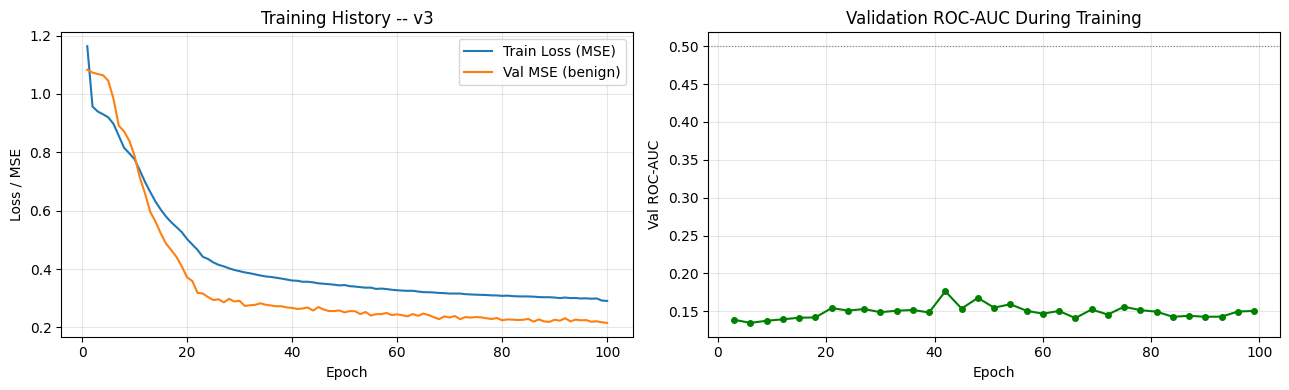

In [9]:
import matplotlib.pyplot as plt

epochs_h = [r['epoch']          for r in history]
train_h  = [r['train_loss']     for r in history]
val_h    = [r['val_mse_benign'] for r in history]
auc_rows = [(r['epoch'], r['val_auc']) for r in history if 'val_auc' in r]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs_h, train_h, label='Train Loss (MSE)', linewidth=1.5)
axes[0].plot(epochs_h, val_h,   label='Val MSE (benign)',   linewidth=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss / MSE')
axes[0].set_title('Training History -- v3')
axes[0].legend()
axes[0].grid(alpha=0.3)

if auc_rows:
    auc_e, auc_v = zip(*auc_rows)
    axes[1].plot(auc_e, auc_v, marker='o', markersize=4, linewidth=1.5, color='green')
    axes[1].axhline(0.5, linestyle=':', color='gray', linewidth=0.8)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Val ROC-AUC')
    axes[1].set_title('Validation ROC-AUC During Training')
    axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RUN_DIR / 'training_history_v3.png', dpi=150)
plt.show()

## 7. Per-Feature Variance Weighting

After training, compute the per-feature reconstruction standard deviation on benign validation windows. Features with low variance under normal traffic (stable features) contribute proportionally more to the anomaly score than naturally noisy features.

This reduces false positives from high-variance benign features dominating the score.

In [10]:
# Compute per-feature reconstruction std on BENIGN validation windows.
# Used to normalize anomaly scores: low-variance features (stable under normal
# traffic) contribute more to the score than naturally noisy features.

X_val_benign = X_val[y_val == 0]
print(f'Computing per-feature reconstruction std from {len(X_val_benign)} benign val windows ...')

model.eval()
sq_errors = []
with torch.no_grad():
    for start in range(0, len(X_val_benign), SCORE_BATCH_SIZE):
        xb    = torch.from_numpy(X_val_benign[start:start + SCORE_BATCH_SIZE]).float().to(device)
        recon = model(xb)
        sq    = (recon - xb).pow(2).cpu().numpy()   # (B, T, F)
        sq_errors.append(sq)
        del xb, recon, sq

sq_errors = np.concatenate(sq_errors, axis=0)                   # (N, T, F)
feat_std  = sq_errors.reshape(-1, sq_errors.shape[2]).std(axis=0) + 1e-6  # (F,)
del sq_errors, X_val_benign
gc.collect()

print(f'feat_std: shape={feat_std.shape}')
print(f'  min={feat_std.min():.6f}  max={feat_std.max():.6f}  mean={feat_std.mean():.6f}')
print(f'  Features with low std (high signal weight): top 5 = {np.argsort(feat_std)[:5].tolist()}')
print(f'  Features with high std (low signal weight): top 5 = {np.argsort(feat_std)[-5:].tolist()}')

Computing per-feature reconstruction std from 3184 benign val windows ...
feat_std: shape=(56,)
  min=0.021237  max=5.085528  mean=0.930266
  Features with low std (high signal weight): top 5 = [55, 0, 38, 4, 26]
  Features with high std (low signal weight): top 5 = [21, 25, 27, 35, 51]


## 8. Anomaly Scoring with Variance Weighting

In [11]:
from sklearn.metrics import roc_auc_score, average_precision_score

# Score with per-feature variance weighting
s_val  = compute_scores(X_val,  feat_std=feat_std)
s_test = compute_scores(X_test, feat_std=feat_std)

print('Val  scores:')
print(f'  min={s_val.min():.6f}  max={s_val.max():.6f}  mean={s_val.mean():.6f}')
print('Test scores:')
print(f'  min={s_test.min():.6f}  max={s_test.max():.6f}  mean={s_test.mean():.6f}')

# Z-score normalization parameters (from BENIGN val scores)
s_benign_val = s_val[y_val == 0]
zscore_mu    = float(s_benign_val.mean())
zscore_sigma = float(s_benign_val.std())
print(f'Z-score params (benign val): mu={zscore_mu:.6f}  sigma={zscore_sigma:.6f}')

# Z-score normalized scores
s_val_z  = (s_val  - zscore_mu) / (zscore_sigma + 1e-9)
s_test_z = (s_test - zscore_mu) / (zscore_sigma + 1e-9)

val_auc  = roc_auc_score(y_val,  s_val)
test_auc = roc_auc_score(y_test, s_test)
print(f'ROC-AUC (raw scores)      -- val: {val_auc:.4f}  test: {test_auc:.4f}')
print(f'ROC-AUC (z-score, same)   -- val: {roc_auc_score(y_val, s_val_z):.4f}  '
      f'test: {roc_auc_score(y_test, s_test_z):.4f}')

# Score separation diagnostic -- the key health check
s_ben_val = s_val[y_val == 0]
s_att_val = s_val[y_val == 1]
gap       = float(s_att_val.mean() - s_ben_val.mean())
print()
print('Score separation (val):')
print(f'  Benign -- mean={s_ben_val.mean():.4f}  std={s_ben_val.std():.4f}  p95={np.percentile(s_ben_val, 95):.4f}')
print(f'  Attack -- mean={s_att_val.mean():.4f}  std={s_att_val.std():.4f}  p05={np.percentile(s_att_val,  5):.4f}')
print(f'  Gap (attack - benign mean): {gap:+.4f}')
if gap > 0:
    print(f'  Direction: CORRECT -- attacks score higher than benign')
else:
    print(f'  Direction: INVERTED -- benign scores higher than attacks (AUC < 0.5)')
    print(f'  ACTION: Re-run mdc_preprocess_v3.ipynb (StandardScaler + clip), export to Drive, then re-run this notebook.')

Val  scores:
  min=0.033017  max=5.481983  mean=0.318107
Test scores:
  min=0.033111  max=3.677050  mean=0.323299
Z-score params (benign val): mu=0.415828  sigma=0.450225
ROC-AUC (raw scores)      -- val: 0.1629  test: 0.1582
ROC-AUC (z-score, same)   -- val: 0.1629  test: 0.1582

Score separation (val):
  Benign -- mean=0.4158  std=0.4502  p95=1.2792
  Attack -- mean=0.1601  std=0.2778  p05=0.0377
  Gap (attack - benign mean): -0.2557
  Direction: INVERTED -- benign scores higher than attacks (AUC < 0.5)
  ACTION: Re-run mdc_preprocess_v3.ipynb (StandardScaler + clip), export to Drive, then re-run this notebook.


## 9. Multiple Thresholding Strategies

| Strategy | Use case |
|---|---|
| `youden_j` | Balanced TPR/FPR — standard baseline |
| `p95/p99_benign` | Guarantee low FPR on training distribution |
| `f1_optimal` | Max F1 on validation |
| `fbeta_0.5` | Precision-priority (FP costs 2× FN) — low alert fatigue |
| `fbeta_2.0` | Recall-priority (FN costs 2× FP) — miss nothing |
| `zscore_2.5/3.0` | Interpretable: flag if score > N sigma above benign mean |
| `precision_0.85` | Minimum 85% precision guarantee |

In [12]:
from sklearn.metrics import roc_curve, precision_recall_curve

PRECISION_TARGET = 0.85

def compute_thresholds(s_val, y_val, zscore_mu, zscore_sigma):
    thresholds = {}
    s_benign   = s_val[y_val == 0]

    # 1. Youden J  (baseline -- max TPR-FPR on ROC)
    fpr_r, tpr_r, thr_roc = roc_curve(y_val, s_val)
    j_idx = int(np.argmax(tpr_r[1:] - fpr_r[1:]))
    thresholds['youden_j'] = float(thr_roc[j_idx])

    # 2-3. Percentile on benign val
    thresholds['p95_benign'] = float(np.percentile(s_benign, 95))
    thresholds['p99_benign'] = float(np.percentile(s_benign, 99))

    # 4. F1-optimal
    prec, rec, thr_pr = precision_recall_curve(y_val, s_val)
    f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
    thresholds['f1_optimal'] = float(thr_pr[int(np.argmax(f1s))])

    # 5. F-beta 0.5  (precision-priority: FP costs 2x as much as FN)
    fb5 = (1 + 0.5**2) * prec[:-1] * rec[:-1] / (0.5**2 * prec[:-1] + rec[:-1] + 1e-9)
    thresholds['fbeta_0.5'] = float(thr_pr[int(np.argmax(fb5))])

    # 6. F-beta 2.0  (recall-priority: FN costs 2x as much as FP -- miss nothing)
    fb2 = (1 + 2.0**2) * prec[:-1] * rec[:-1] / (2.0**2 * prec[:-1] + rec[:-1] + 1e-9)
    thresholds['fbeta_2.0'] = float(thr_pr[int(np.argmax(fb2))])

    # 7-8. Z-score: threshold expressed as raw score value
    # "Flag if score is N sigma above benign mean" -- interpretable & scale-invariant
    thresholds['zscore_2.5'] = float(zscore_mu + 2.5 * zscore_sigma)
    thresholds['zscore_3.0'] = float(zscore_mu + 3.0 * zscore_sigma)

    # 9. Precision-target (lowest threshold where precision >= 0.85)
    valid = np.where(prec[:-1] >= PRECISION_TARGET)[0]
    thresholds['precision_0.85'] = (float(thr_pr[valid[-1]]) if len(valid) > 0
                                    else thresholds['p99_benign'])

    return thresholds


thresholds = compute_thresholds(s_val, y_val, zscore_mu, zscore_sigma)
print('Thresholds from validation set:')
for name, val in thresholds.items():
    print(f'  {name:18s}: {val:.6f}')

Thresholds from validation set:
  youden_j          : 0.037311
  p95_benign        : 1.279195
  p99_benign        : 2.183728
  f1_optimal        : 0.033017
  fbeta_0.5         : 0.033017
  fbeta_2.0         : 0.033017
  zscore_2.5        : 1.541391
  zscore_3.0        : 1.766504
  precision_0.85    : 2.183728


## 10. Complete Test Evaluation

In [13]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, f1_score, matthews_corrcoef, balanced_accuracy_score,
)


def full_eval(s, y, threshold, label=''):
    y_pred = (s >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, y_pred, labels=[0, 1]).ravel()

    roc_auc   = roc_auc_score(y, s)
    pr_auc    = average_precision_score(y, s)
    f1        = f1_score(y, y_pred, zero_division=0)
    mcc       = matthews_corrcoef(y, y_pred)
    bal_acc   = balanced_accuracy_score(y, y_pred)
    fpr       = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr       = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    result = dict(
        threshold=threshold, roc_auc=roc_auc, pr_auc=pr_auc,
        f1=f1, mcc=mcc, balanced_acc=bal_acc,
        precision=precision, recall=recall, fpr=fpr, fnr=fnr,
        tp=int(tp), fp=int(fp), tn=int(tn), fn=int(fn),
    )
    if label:
        print(f'=== {label} ===')
        print(f'  Threshold  : {threshold:.6f}')
        print(f'  ROC-AUC    : {roc_auc:.4f}   PR-AUC  : {pr_auc:.4f}')
        print(f'  F1         : {f1:.4f}   MCC     : {mcc:.4f}   BalAcc: {bal_acc:.4f}')
        print(f'  Precision  : {precision:.4f}   Recall  : {recall:.4f}')
        print(f'  FPR        : {fpr:.4f}   FNR     : {fnr:.4f}')
        print(f'  Confusion  : TP={tp} FP={fp} TN={tn} FN={fn}')
    return result


print('Test-set evaluation (all threshold strategies):')
print()
all_results = {}
for name, thr in thresholds.items():
    all_results[name] = full_eval(s_test, y_test, thr, label=name)

print()
print('=' * 85)
print(f'{"Strategy":<18} {"ROC-AUC":>8} {"PR-AUC":>8} {"F1":>7}'
      f' {"MCC":>7} {"BalAcc":>8} {"FPR":>7} {"FNR":>7}')
print('-' * 85)
for name, r in all_results.items():
    print(f'{name:<18} {r["roc_auc"]:>8.4f} {r["pr_auc"]:>8.4f}'
          f' {r["f1"]:>7.4f} {r["mcc"]:>7.4f} {r["balanced_acc"]:>8.4f}'
          f' {r["fpr"]:>7.4f} {r["fnr"]:>7.4f}')
print('=' * 85)

Test-set evaluation (all threshold strategies):

=== youden_j ===
  Threshold  : 0.037311
  ROC-AUC    : 0.1582   PR-AUC  : 0.2437
  F1         : 0.5345   MCC     : -0.1666   BalAcc: 0.4775
  Precision  : 0.3711   Recall  : 0.9548
  FPR        : 0.9997   FNR     : 0.0452
  Confusion  : TP=1879 FP=3184 TN=1 FN=89
=== p95_benign ===
  Threshold  : 1.279195
  ROC-AUC    : 0.1582   PR-AUC  : 0.2437
  F1         : 0.0202   MCC     : -0.1171   BalAcc: 0.4762
  Precision  : 0.1053   Recall  : 0.0112
  FPR        : 0.0587   FNR     : 0.9888
  Confusion  : TP=22 FP=187 TN=2998 FN=1946
=== p99_benign ===
  Threshold  : 2.183728
  ROC-AUC    : 0.1582   PR-AUC  : 0.2437
  F1         : 0.0020   MCC     : -0.0688   BalAcc: 0.4931
  Precision  : 0.0408   Recall  : 0.0010
  FPR        : 0.0148   FNR     : 0.9990
  Confusion  : TP=2 FP=47 TN=3138 FN=1966
=== f1_optimal ===
  Threshold  : 0.033017
  ROC-AUC    : 0.1582   PR-AUC  : 0.2437
  F1         : 0.5527   MCC     : 0.0000   BalAcc: 0.5000
  Precis

## 11. Score Distribution & ROC/PR Curves

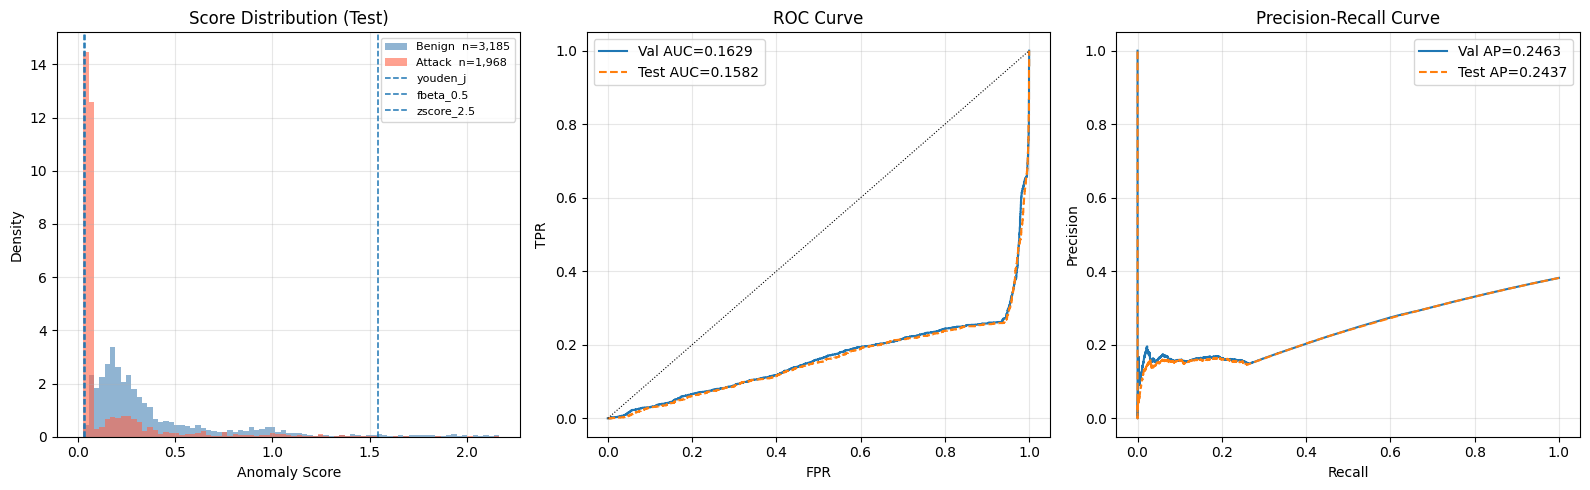

Plots saved.


In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Score distribution (test set)
ax   = axes[0]
s_bn = s_test[y_test == 0]
s_at = s_test[y_test == 1]
hi   = np.percentile(s_test, 99)
bins = np.linspace(0, hi, 80)
ax.hist(s_bn, bins=bins, alpha=0.6, density=True,
        color='steelblue', label=f'Benign  n={len(s_bn):,}')
ax.hist(s_at, bins=bins, alpha=0.6, density=True,
        color='tomato',    label=f'Attack  n={len(s_at):,}')
for name in ('youden_j', 'fbeta_0.5', 'zscore_2.5'):
    if name in thresholds:
        ax.axvline(thresholds[name], linestyle='--', linewidth=1.1, label=name)
ax.set_xlabel('Anomaly Score')
ax.set_ylabel('Density')
ax.set_title('Score Distribution (Test)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 2. ROC curve
ax = axes[1]
for split, s, y, ls in [('Val', s_val, y_val, '-'), ('Test', s_test, y_test, '--')]:
    fp_r, tp_r, _ = roc_curve(y, s)
    auc = roc_auc_score(y, s)
    ax.plot(fp_r, tp_r, linestyle=ls, label=f'{split} AUC={auc:.4f}')
ax.plot([0, 1], [0, 1], 'k:', linewidth=0.8)
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('ROC Curve')
ax.legend()
ax.grid(alpha=0.3)

# 3. Precision-Recall curve
ax = axes[2]
for split, s, y, ls in [('Val', s_val, y_val, '-'), ('Test', s_test, y_test, '--')]:
    pr, rc, _ = precision_recall_curve(y, s)
    ap = average_precision_score(y, s)
    ax.plot(rc, pr, linestyle=ls, label=f'{split} AP={ap:.4f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RUN_DIR / 'evaluation_plots_v3.png', dpi=150)
plt.show()
print('Plots saved.')

## 12. Optuna HPO

Search space includes `bottleneck_dim` in {16, 32}.
Objective: val ROC-AUC (unweighted scores — feat_std not available inside HPO trials).

In [15]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


def hpo_objective(trial: optuna.Trial) -> float:
    d_model        = trial.suggest_categorical('d_model',        [32, 64, 128])
    bottleneck_dim = trial.suggest_categorical('bottleneck_dim', [16, 32])
    num_enc_layers = trial.suggest_int('num_enc_layers', 1, 3)
    num_dec_layers = trial.suggest_int('num_dec_layers', 1, 2)
    dim_ff         = trial.suggest_categorical('dim_ff',         [96, 192, 256])
    dropout        = trial.suggest_float('dropout',    0.05, 0.30)
    lr             = trial.suggest_float('lr',         1e-4, 5e-3, log=True)
    noise_std      = trial.suggest_float('noise_std',  0.01, 0.10)

    if bottleneck_dim >= d_model:
        raise optuna.exceptions.TrialPruned()

    nhead = 4 if d_model % 4 == 0 else 2
    m = build_model(
        n_features=n_features, d_model=d_model, nhead=nhead,
        num_enc_layers=num_enc_layers, num_dec_layers=num_dec_layers,
        dim_ff=dim_ff, dropout=dropout, bottleneck_dim=bottleneck_dim,
    )
    loader = DataLoader(
        TensorDataset(X_train_t), batch_size=BATCH_SIZE,
        shuffle=True, drop_last=False, pin_memory=False, num_workers=0,
    )
    opt_m   = optim.AdamW(m.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    xv_b    = X_val_t[y_val == 0].to(device)
    best_v, no_imp = float('inf'), 0

    for epoch in range(1, HPO_MAX_EPOCH + 1):
        m.train()
        for (xb,) in loader:
            xb = xb.to(device)
            opt_m.zero_grad(set_to_none=True)
            loss = F.mse_loss(m(add_noise(xb, noise_std)), xb)
            loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), GRAD_CLIP)
            opt_m.step()

        m.eval()
        with torch.no_grad():
            v_mse = float(F.mse_loss(m(xv_b), xv_b).item())

        trial.report(v_mse, epoch)
        if trial.should_prune():
            del m, opt_m, xv_b, loader
            gc.collect()
            raise optuna.exceptions.TrialPruned()

        if v_mse < best_v - 1e-6:
            best_v, no_imp = v_mse, 0
        else:
            no_imp += 1
        if no_imp >= HPO_PATIENCE:
            break

    # Score val and compute ROC-AUC (unweighted -- feat_std not available in HPO)
    s_chunks = []
    m.eval()
    with torch.no_grad():
        for start in range(0, len(X_val), SCORE_BATCH_SIZE):
            xb    = torch.from_numpy(X_val[start:start + SCORE_BATCH_SIZE]).float().to(device)
            recon = m(xb)
            err   = (recon - xb).pow(2)
            s_chunks.append(
                (SCORE_MEAN_W * err.mean(dim=(1, 2)) +
                 SCORE_MAX_W  * err.mean(dim=2).amax(dim=1)).cpu().numpy()
            )
            del xb, recon, err
    s_v = np.concatenate(s_chunks)

    del m, opt_m, xv_b, loader, s_chunks
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    try:
        return float(roc_auc_score(y_val, s_v))
    except Exception:
        return 0.5


study = optuna.create_study(
    direction='maximize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10),
    study_name='mdc_v3_hpo',
)
print(f'Starting Optuna HPO: {N_TRIALS} trials, {HPO_MAX_EPOCH} epochs each ...')
study.optimize(hpo_objective, n_trials=N_TRIALS, show_progress_bar=True)

best = study.best_trial
print(f'Best Val ROC-AUC: {best.value:.4f}')
print(f'Best params     : {best.params}')
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Starting Optuna HPO: 15 trials, 30 epochs each ...


  0%|          | 0/15 [00:00<?, ?it/s]

/tmp/ipykernel_676/2926076753.py:54: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)
/tmp/ipykernel_676/2926076753.py:54: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)
/tmp/ipykernel_676/2926076753.py:54: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)
/tmp/ipykernel_676/2926076753.py:54: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)
/tmp/ipykernel_676/2926076753.py:54: UserWarning: enable_nes

Best Val ROC-AUC: 0.2394
Best params     : {'d_model': 64, 'bottleneck_dim': 16, 'num_enc_layers': 2, 'num_dec_layers': 2, 'dim_ff': 256, 'dropout': 0.09152453852938454, 'lr': 0.0013286727469416285, 'noise_std': 0.09950156812692594}


## 13. Retrain with Best HPO Params

In [16]:
print('Retraining with best HPO params ...')
bp         = best.params
nhead_best = 4 if bp['d_model'] % 4 == 0 else 2

model_best = build_model(
    n_features=n_features,
    d_model=bp['d_model'],         nhead=nhead_best,
    num_enc_layers=bp['num_enc_layers'],
    num_dec_layers=bp['num_dec_layers'],
    dim_ff=bp['dim_ff'],           dropout=bp['dropout'],
    bottleneck_dim=bp['bottleneck_dim'],
)
loader_best = DataLoader(
    TensorDataset(X_train_t), batch_size=BATCH_SIZE,
    shuffle=True, drop_last=False, pin_memory=False, num_workers=0,
)
_, history_best = train_model(
    model_best, loader_best, X_val_t, y_val,
    lr=bp['lr'],
    noise_std=bp['noise_std'],
    use_denoising=True,
    verbose=True,
)
del loader_best
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Re-compute feat_std for the best model
model = model_best
X_val_benign_hpo = X_val[y_val == 0]
sq_err_hpo       = []
model.eval()
with torch.no_grad():
    for start in range(0, len(X_val_benign_hpo), SCORE_BATCH_SIZE):
        xb    = torch.from_numpy(X_val_benign_hpo[start:start + SCORE_BATCH_SIZE]).float().to(device)
        recon = model(xb)
        sq_err_hpo.append((recon - xb).pow(2).cpu().numpy())
        del xb, recon
sq_err_hpo = np.concatenate(sq_err_hpo, axis=0)
feat_std_best = sq_err_hpo.reshape(-1, sq_err_hpo.shape[2]).std(axis=0) + 1e-6
del sq_err_hpo, X_val_benign_hpo
gc.collect()

s_val_best  = compute_scores(X_val,  feat_std=feat_std_best)
s_test_best = compute_scores(X_test, feat_std=feat_std_best)

zscore_mu_b    = float(s_val_best[y_val == 0].mean())
zscore_sigma_b = float(s_val_best[y_val == 0].std())
thresholds_best = compute_thresholds(s_val_best, y_val, zscore_mu_b, zscore_sigma_b)

print()
print('=== HPO Best Model -- Test Evaluation ===')
print(f'{"Strategy":<18} {"ROC-AUC":>8} {"PR-AUC":>8} {"F1":>7}'
      f' {"MCC":>7} {"BalAcc":>8} {"FPR":>7} {"FNR":>7}')
print('-' * 85)
for name, thr in thresholds_best.items():
    r = full_eval(s_test_best, y_test, thr)
    print(f'{name:<18} {r["roc_auc"]:>8.4f} {r["pr_auc"]:>8.4f}'
          f' {r["f1"]:>7.4f} {r["mcc"]:>7.4f} {r["balanced_acc"]:>8.4f}'
          f' {r["fpr"]:>7.4f} {r["fnr"]:>7.4f}')
print('=' * 85)

Retraining with best HPO params ...


/tmp/ipykernel_676/2926076753.py:54: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)


epoch 001  train=1.017057  val_benign=1.068540  lr=1.33e-03 *
epoch 002  train=0.905022  val_benign=1.025084  lr=1.33e-03 *
epoch 003  train=0.820646  val_benign=0.845999  lr=1.33e-03  val_auc=0.1587 *
epoch 004  train=0.686901  val_benign=0.667960  lr=1.33e-03 *
epoch 005  train=0.572003  val_benign=0.546049  lr=1.33e-03 *
epoch 006  train=0.502281  val_benign=0.460989  lr=1.33e-03  val_auc=0.1831 *
epoch 007  train=0.457664  val_benign=0.427537  lr=1.33e-03 *
epoch 008  train=0.433443  val_benign=0.373815  lr=1.33e-03 *
epoch 009  train=0.401603  val_benign=0.351250  lr=1.33e-03  val_auc=0.1710 *
epoch 010  train=0.381084  val_benign=0.338289  lr=1.33e-03 *
epoch 011  train=0.364526  val_benign=0.321857  lr=1.33e-03 *
epoch 012  train=0.349383  val_benign=0.302538  lr=1.33e-03  val_auc=0.2037 *
epoch 013  train=0.339318  val_benign=0.281947  lr=1.33e-03 *
epoch 014  train=0.324606  val_benign=0.269147  lr=1.33e-03 *
epoch 015  train=0.313871  val_benign=0.277566  lr=1.33e-03  val_auc

## 14. Save Final Model & Artifacts

In [17]:
from datetime import datetime, timezone

torch.save({
    'model'      : model_best.state_dict(),
    'hpo_params' : bp,
    'val_roc_auc': best.value,
    'feat_std'   : feat_std_best,
    'zscore_mu'  : zscore_mu_b,
    'zscore_sigma': zscore_sigma_b,
    'config': {
        'T': T, 'n_features': n_features,
        'd_model'        : bp['d_model'],
        'bottleneck_dim' : bp['bottleneck_dim'],
        'nhead'          : nhead_best,
        'num_enc_layers' : bp['num_enc_layers'],
        'num_dec_layers' : bp['num_dec_layers'],
        'dim_ff'         : bp['dim_ff'],
        'dropout'        : bp['dropout'],
    },
}, RUN_DIR / 'checkpoint_v3_best.pt')

np.savez_compressed(
    RUN_DIR / 'scores_v3.npz',
    s_val=s_val_best, s_test=s_test_best,
    y_val=y_val, y_test=y_test,
    feat_std=feat_std_best,
)

thr_report = thresholds_best['youden_j']
final      = full_eval(s_test_best, y_test, thr_report)

summary = {
    'created_at'       : datetime.now(timezone.utc).isoformat(),
    'version'          : 'v3',
    'hpo_params'       : bp,
    'thresholds'       : thresholds_best,
    'default_threshold': thr_report,
    'test_roc_auc'     : final['roc_auc'],
    'test_pr_auc'      : final['pr_auc'],
    'test_f1'          : final['f1'],
    'test_mcc'         : final['mcc'],
    'test_balanced_acc': final['balanced_acc'],
    'test_precision'   : final['precision'],
    'test_recall'      : final['recall'],
    'test_fpr'         : final['fpr'],
    'test_fnr'         : final['fnr'],
    'confusion'        : {'tp': final['tp'], 'fp': final['fp'],
                          'tn': final['tn'], 'fn': final['fn']},
    'train_shapes'     : {
        'X_train': list(X_train_t.shape),
        'X_val'  : list(X_val.shape),
        'X_test' : list(X_test.shape),
    },
    'zscore_mu'   : zscore_mu_b,
    'zscore_sigma': zscore_sigma_b,
}
(RUN_DIR / 'metrics_v3.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')

print('All artifacts saved to:', RUN_DIR)
print(json.dumps({k: round(v, 4) for k, v in {
    'test_roc_auc'     : final['roc_auc'],
    'test_pr_auc'      : final['pr_auc'],
    'test_f1'          : final['f1'],
    'test_mcc'         : final['mcc'],
    'test_balanced_acc': final['balanced_acc'],
    'test_fpr'         : final['fpr'],
    'test_fnr'         : final['fnr'],
}.items()}, indent=2))

All artifacts saved to: /content/drive/MyDrive/Module4_MDC/runs/v3_run
{
  "test_roc_auc": 0.2573,
  "test_pr_auc": 0.2705,
  "test_f1": 0.5527,
  "test_mcc": 0.0104,
  "test_balanced_acc": 0.5005,
  "test_fpr": 0.9975,
  "test_fnr": 0.0015
}


## 15. Fallback: Default-Config Model (No HPO)

In [18]:
# Reload and evaluate the default-config model (no HPO)
# Useful if HPO was skipped or timed out
ckpt    = torch.load(RUN_DIR / 'checkpoint_v3.pt', map_location=device)
cfg     = ckpt['config']
m_def   = build_model(
    n_features=cfg['n_features'],     d_model=cfg['d_model'],
    bottleneck_dim=cfg['bottleneck_dim'],
    num_enc_layers=cfg['num_enc_layers'],
    num_dec_layers=cfg['num_dec_layers'],
    dim_ff=cfg['dim_ff'],             dropout=cfg['dropout'],
)
m_def.load_state_dict(ckpt['model'])
m_def.eval()
del ckpt
gc.collect()

_prev_model = model
model       = m_def

# Compute feat_std for default model
X_vb_def   = X_val[y_val == 0]
sq_def     = []
with torch.no_grad():
    for start in range(0, len(X_vb_def), SCORE_BATCH_SIZE):
        xb    = torch.from_numpy(X_vb_def[start:start + SCORE_BATCH_SIZE]).float().to(device)
        recon = model(xb)
        sq_def.append((recon - xb).pow(2).cpu().numpy())
        del xb, recon
sq_def       = np.concatenate(sq_def, axis=0)
feat_std_def = sq_def.reshape(-1, sq_def.shape[2]).std(axis=0) + 1e-6
del sq_def, X_vb_def
gc.collect()

s_val_def    = compute_scores(X_val,  feat_std=feat_std_def)
s_test_def   = compute_scores(X_test, feat_std=feat_std_def)
zm_d         = float(s_val_def[y_val == 0].mean())
zs_d         = float(s_val_def[y_val == 0].std())
thr_def      = compute_thresholds(s_val_def, y_val, zm_d, zs_d)
r_def        = full_eval(s_test_def, y_test, thr_def['youden_j'], label='default/youden_j')

model = _prev_model
del m_def, _prev_model
gc.collect()
print(f'Default model -- ROC-AUC: {r_def["roc_auc"]:.4f}  F1: {r_def["f1"]:.4f}')

/tmp/ipykernel_676/2926076753.py:54: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)


=== default/youden_j ===
  Threshold  : 0.037311
  ROC-AUC    : 0.1582   PR-AUC  : 0.2437
  F1         : 0.5345   MCC     : -0.1666   BalAcc: 0.4775
  Precision  : 0.3711   Recall  : 0.9548
  FPR        : 0.9997   FNR     : 0.0452
  Confusion  : TP=1879 FP=3184 TN=1 FN=89
Default model -- ROC-AUC: 0.1582  F1: 0.5345
